## 102 Flowers classification with ResNet 50 (04/09/2025)

In [59]:
import os
import random
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.layers import Dense, Flatten, Lambda
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.applications.resnet50 import preprocess_input

from PIL import Image
from scipy.io import loadmat
from sklearn.model_selection import train_test_split

### Load images 

In [2]:
image_dir = './data/102flowers/jpg'  # Replace with your image directory path

data = []

# Iterate through all .jpg files in the directory
for filename in os.listdir(image_dir):
    if filename.endswith('.jpg'):
        file_path = os.path.join(image_dir, filename)
        
        # Open the image using Pillow
        with Image.open(file_path) as img:
            # Resize for ResNet
            img = img.resize((224, 224))
            
            img_array = np.array(img)
            data.append({'filename': filename, 'image': img_array})

df = pd.DataFrame(data)

In [3]:
df.head(10)

,filename,image
0,image_00001.jpg,"[[[125, 119, 95], [118, 112, 87], [105, 100, 7..."
1,image_00002.jpg,"[[[2, 64, 30], [5, 68, 34], [6, 69, 35], [1, 6..."
2,image_00003.jpg,"[[[2, 2, 0], [2, 2, 0], [2, 2, 0], [2, 2, 0], ..."
3,image_00004.jpg,"[[[169, 189, 180], [170, 190, 181], [171, 191,..."
4,image_00005.jpg,"[[[44, 54, 37], [41, 54, 36], [39, 55, 36], [3..."
5,image_00006.jpg,"[[[34, 59, 20], [30, 60, 20], [31, 67, 24], [3..."
6,image_00007.jpg,"[[[90, 125, 29], [79, 112, 18], [65, 95, 8], [..."
7,image_00008.jpg,"[[[73, 99, 36], [71, 98, 30], [74, 102, 29], [..."
8,image_00009.jpg,"[[[71, 143, 35], [72, 144, 35], [76, 148, 38],..."
9,image_00010.jpg,"[[[31, 37, 25], [28, 34, 22], [27, 32, 20], [2..."


In [4]:
df.shape

(8189, 2)

In [5]:
df.isnull().sum()

filename    0
image       0
dtype: int64

### Get labels

In [6]:
labels_data = loadmat('./data/imagelabels.mat')
labels = labels_data['labels'][0]
labels

array([77, 77, 77, ..., 62, 62, 62], dtype=uint8)

In [7]:
df["label"] = labels

In [8]:
df.head(5)

,filename,image,label
0,image_00001.jpg,"[[[125, 119, 95], [118, 112, 87], [105, 100, 7...",77
1,image_00002.jpg,"[[[2, 64, 30], [5, 68, 34], [6, 69, 35], [1, 6...",77
2,image_00003.jpg,"[[[2, 2, 0], [2, 2, 0], [2, 2, 0], [2, 2, 0], ...",77
3,image_00004.jpg,"[[[169, 189, 180], [170, 190, 181], [171, 191,...",77
4,image_00005.jpg,"[[[44, 54, 37], [41, 54, 36], [39, 55, 36], [3...",77


In [9]:
df.drop(columns=['filename'])

,image,label
0,"[[[125, 119, 95], [118, 112, 87], [105, 100, 7...",77
1,"[[[2, 64, 30], [5, 68, 34], [6, 69, 35], [1, 6...",77
2,"[[[2, 2, 0], [2, 2, 0], [2, 2, 0], [2, 2, 0], ...",77
3,"[[[169, 189, 180], [170, 190, 181], [171, 191,...",77
4,"[[[44, 54, 37], [41, 54, 36], [39, 55, 36], [3...",77
...,...,...
8184,"[[[64, 62, 43], [68, 68, 43], [59, 61, 35], [3...",62
8185,"[[[17, 17, 17], [17, 17, 17], [17, 17, 17], [1...",62
8186,"[[[19, 17, 10], [22, 19, 12], [34, 29, 23], [5...",62
8187,"[[[60, 97, 1], [59, 96, 0], [59, 96, 0], [59, ...",62


## EDA

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8189 entries, 0 to 8188
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   filename  8189 non-null   object
 1   image     8189 non-null   object
 2   label     8189 non-null   uint8 
dtypes: object(2), uint8(1)
memory usage: 136.1+ KB


In [11]:
df.isnull().sum()

filename    0
image       0
label       0
dtype: int64

In [12]:
df.label.value_counts()

label
51    258
77    251
46    196
73    194
89    184
     ... 
7      40
45     40
34     40
1      40
27     40
Name: count, Length: 102, dtype: int64

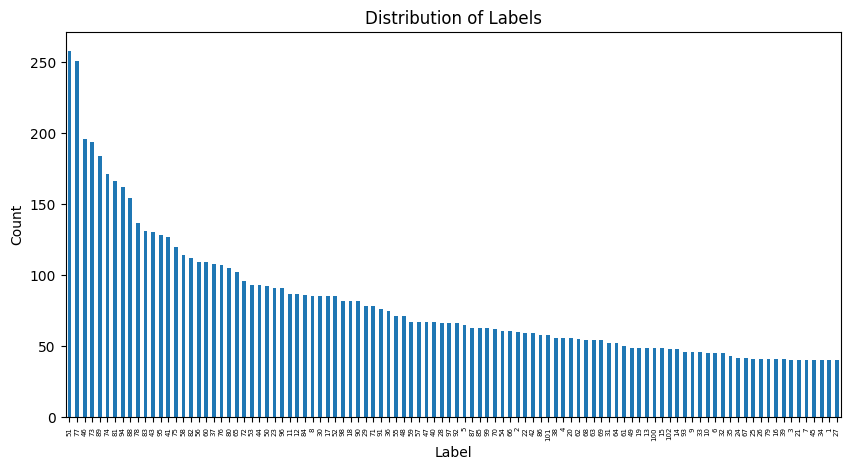

In [13]:
label_counts = df['label'].value_counts()
plt.figure(figsize=(10, 5))
label_counts.plot(kind='bar')
plt.xticks(fontsize=5, rotation=90)
plt.title("Distribution of Labels")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()

* We have at least 40 images for each category.
* We might need to watch out for numbers of images for each category when training.

In [14]:
# Path to your JSON file
file_path = './data/cat_to_name.json'

# Open and load the JSON file into a dictionary
with open(file_path, 'r') as file:
    i_to_name = json.load(file)

# Print the dictionary
i_to_name = {int(key): value for key, value in i_to_name.items()}
i_to_name

{21: 'fire lily',
 3: 'canterbury bells',
 45: 'bolero deep blue',
 1: 'pink primrose',
 34: 'mexican aster',
 27: 'prince of wales feathers',
 7: 'moon orchid',
 16: 'globe-flower',
 25: 'grape hyacinth',
 26: 'corn poppy',
 79: 'toad lily',
 39: 'siam tulip',
 24: 'red ginger',
 67: 'spring crocus',
 35: 'alpine sea holly',
 32: 'garden phlox',
 10: 'globe thistle',
 6: 'tiger lily',
 93: 'ball moss',
 33: 'love in the mist',
 9: 'monkshood',
 102: 'blackberry lily',
 14: 'spear thistle',
 19: 'balloon flower',
 100: 'blanket flower',
 13: 'king protea',
 49: 'oxeye daisy',
 15: 'yellow iris',
 61: 'cautleya spicata',
 31: 'carnation',
 64: 'silverbush',
 68: 'bearded iris',
 63: 'black-eyed susan',
 69: 'windflower',
 62: 'japanese anemone',
 20: 'giant white arum lily',
 38: 'great masterwort',
 4: 'sweet pea',
 86: 'tree mallow',
 101: 'trumpet creeper',
 42: 'daffodil',
 22: 'pincushion flower',
 2: 'hard-leaved pocket orchid',
 54: 'sunflower',
 66: 'osteospermum',
 70: 'tree po

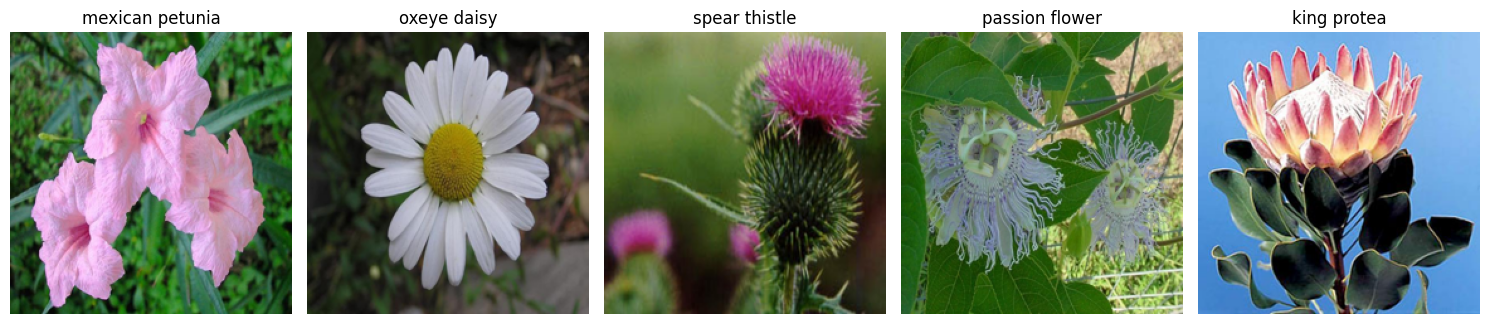

In [15]:
# Function to visualize random images
def visualize_samples(df, num_samples=5):
    plt.figure(figsize=(15, 5))
    for i in range(num_samples):
        idx = random.randint(0, len(df) - 1)
        img = df.iloc[idx]['image']
        label = df.iloc[idx]['label']
        plt.subplot(1, num_samples, i + 1)
        plt.imshow(img)
        plt.title(f"{i_to_name[label]}")
        plt.axis('off')
    plt.tight_layout()
    plt.show()

# Visualize 5 random samples
visualize_samples(df, num_samples=5)

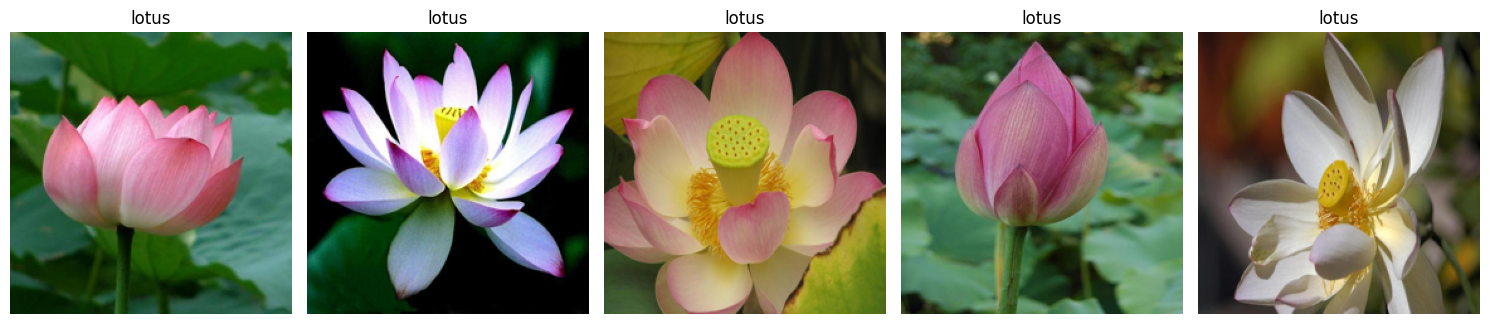

In [16]:
df2 = df[df.label == 78]

visualize_samples(df2, num_samples=5)

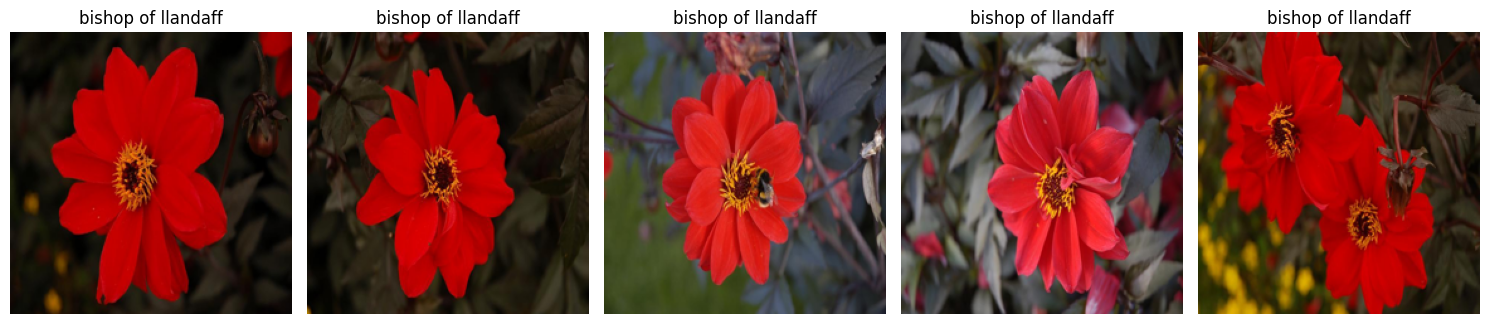

In [17]:
df2 = df[df.label == 56]

visualize_samples(df2, num_samples=5)

## Preprocessing

In [50]:
img_height, img_width = 224, 224

images = np.stack(df['image'].values)
labels = df['label'].values - 1

X_train, X_temp, y_train, y_temp = train_test_split(images, labels, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

y_train = to_categorical(y_train, num_classes=102)
y_val = to_categorical(y_val, num_classes=102)
y_test = to_categorical(y_test, num_classes=102)

# One-hot encode the labels
train_dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train)).batch(16).shuffle(1000)
val_dataset = tf.data.Dataset.from_tensor_slices((X_val, y_val)).batch(16)
test_dataset = tf.data.Dataset.from_tensor_slices((X_test, y_test)).batch(16)


print(f"Train dataset: {len(X_train)} samples")
print(f"Validation dataset: {len(X_val)} samples")
print(f"Test dataset: {len(X_test)} samples")
print(f"y_train shape: {y_train.shape}")
print(f"y_val shape: {y_val.shape}")
print(f"y_test shape: {y_test.shape}")

Train dataset: 5732 samples
Validation dataset: 1228 samples
Test dataset: 1229 samples
y_train shape: (5732, 102)
y_val shape: (1228, 102)
y_test shape: (1229, 102)


## Training

In [51]:
pretrained_model = tf.keras.applications.ResNet50(include_top=False,
                                                  input_shape=(img_height, img_height, 3),
                                                  pooling="avg",
                                                  classes=102,
                                                  weights="imagenet")

for layer in pretrained_model.layers:
    layer.trainable=False
    
resnet_model = Sequential([
    tf.keras.applications.ResNet50(include_top=False, 
                                   input_shape=(img_height, img_width, 3),
                                   pooling="avg", 
                                   weights="imagenet"),
    Flatten(),
    Dense(512, activation="relu"),
    Dense(102, activation="softmax")
])


In [52]:
resnet_model.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 2048)           │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 102)            │        52,326 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,689,126 (94.18 MB)

 Trainable params: 24,636,006 (93.98 MB)

 Non-trainable params: 53,120 (207.50 KB)

In [53]:
resnet_model.compile(optimizer=Adam(learning_rate=0.001), 
                     loss='categorical_crossentropy',
                     metrics=['accuracy'])

In [54]:
epochs=10
history = resnet_model.fit(
	train_dataset,
	validation_data=val_dataset,
	epochs=epochs
)

Epoch 1/10


359/359 ━━━━━━━━━━━━━━━━━━━━ 1216s 3s/step - accuracy: 0.1312 - loss: 4.0884 - val_accuracy: 0.0806 - val_loss: 4.6217
Epoch 2/10
359/359 ━━━━━━━━━━━━━━━━━━━━ 1095s 3s/step - accuracy: 0.4228 - loss: 2.1860 - val_accuracy: 0.1897 - val_loss: 4.1477
Epoch 3/10
359/359 ━━━━━━━━━━━━━━━━━━━━ 1098s 3s/step - accuracy: 0.6536 - loss: 1.1927 - val_accuracy: 0.5228 - val_loss: 1.9440
Epoch 4/10
359/359 ━━━━━━━━━━━━━━━━━━━━ 1096s 3s/step - accuracy: 0.8159 - loss: 0.6218 - val_accuracy: 0.5855 - val_loss: 1.5844
Epoch 5/10
359/359 ━━━━━━━━━━━━━━━━━━━━ 1107s 3s/step - accuracy: 0.8812 - loss: 0.3669 - val_accuracy: 0.6482 - val_loss: 1.3994
Epoch 6/10
359/359 ━━━━━━━━━━━━━━━━━━━━ 1107s 3s/step - accuracy: 0.9151 - loss: 0.2588 - val_accuracy: 0.6433 - val_loss: 1.6321
Epoch 7/10
359/359 ━━━━━━━━━━━━━━━━━━━━ 1121s 3s/step - accuracy: 0.9412 - loss: 0.1849 - val_accuracy: 0.4821 - val_loss: 2.9107
Epoch 8/10
359/359 ━━━━━━━━━━━━━━━━━━━━ 1116s 3s/step - accuracy: 0.9511 - loss: 0.1572 - val_accurac

In [62]:
def graph_result(history):
	fig = plt.gcf()
	plt.plot(history.history['accuracy'])
	plt.plot(history.history['val_accuracy'])
	plt.axis(ymin=0.4,ymax=1)
	plt.grid()
	plt.title('Model Accuracy')
	plt.ylabel('Accuracy')
	plt.xlabel('Epochs')
	plt.legend(['train', 'validation'])
	plt.show()

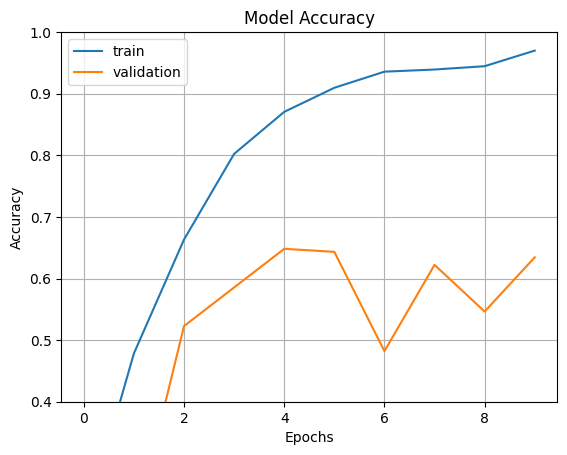

In [ ]:
graph_result(history)

* It looks like my model is overfitting. Let's see if I can improve it.

* According to Resnet's documentation, it expect BGR instead of RGB. I need to convert the image and retrain. 

In [61]:
pretrained_model = tf.keras.applications.ResNet50(include_top=False,
                                                  input_shape=(img_height, img_height, 3),
                                                  pooling="avg",
                                                  classes=102,
                                                  weights="imagenet")

for layer in pretrained_model.layers:
    layer.trainable=False
    
resnet_model = Sequential([
    Lambda(preprocess_input, input_shape=(img_height, img_width, 3)),  # Preprocessing layer
    tf.keras.applications.ResNet50(include_top=False, 
                                   input_shape=(img_height, img_width, 3),
                                   pooling="avg", 
                                   weights="imagenet"),
    Flatten(),
    Dense(512, activation="relu"),
    Dense(102, activation="softmax")
])

resnet_model.compile(optimizer=Adam(learning_rate=0.001), 
                     loss='categorical_crossentropy',
                     metrics=['accuracy'])

epochs=10
history = resnet_model.fit(
	train_dataset,
	validation_data=val_dataset,
	epochs=epochs
)

Epoch 1/10
359/359 ━━━━━━━━━━━━━━━━━━━━ 1212s 3s/step - accuracy: 0.1400 - loss: 3.9468 - val_accuracy: 0.1417 - val_loss: 5.5775
Epoch 2/10
359/359 ━━━━━━━━━━━━━━━━━━━━ 1148s 3s/step - accuracy: 0.5482 - loss: 1.6273 - val_accuracy: 0.4764 - val_loss: 2.1748
Epoch 3/10
359/359 ━━━━━━━━━━━━━━━━━━━━ 1152s 3s/step - accuracy: 0.7622 - loss: 0.8105 - val_accuracy: 0.6083 - val_loss: 1.5744
Epoch 4/10
359/359 ━━━━━━━━━━━━━━━━━━━━ 1175s 3s/step - accuracy: 0.8828 - loss: 0.4083 - val_accuracy: 0.6327 - val_loss: 1.5896
Epoch 5/10
359/359 ━━━━━━━━━━━━━━━━━━━━ 1165s 3s/step - accuracy: 0.9108 - loss: 0.2968 - val_accuracy: 0.6645 - val_loss: 1.4705
Epoch 6/10
359/359 ━━━━━━━━━━━━━━━━━━━━ 1167s 3s/step - accuracy: 0.9219 - loss: 0.2435 - val_accuracy: 0.7150 - val_loss: 1.1744
Epoch 7/10
359/359 ━━━━━━━━━━━━━━━━━━━━ 1154s 3s/step - accuracy: 0.9539 - loss: 0.1546 - val_accuracy: 0.6621 - val_loss: 1.4687
Epoch 8/10
359/359 ━━━━━━━━━━━━━━━━━━━━ 1166s 3s/step - accuracy: 0.9350 - loss: 0.2089 - 

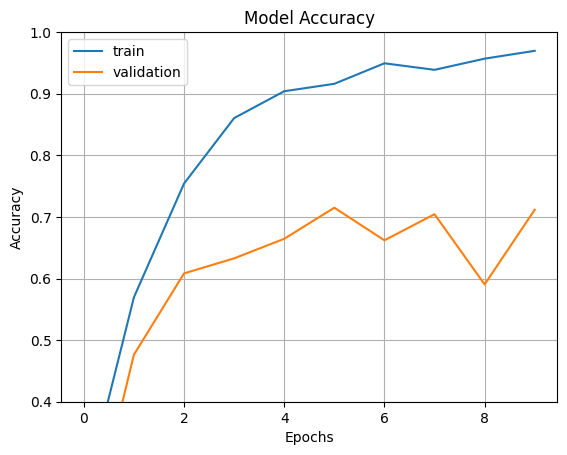

In [63]:
graph_result(history)

* Definitely an improvement with preprocessing.

In [69]:
predictions = resnet_model.predict(test_dataset)
predicted_labels = np.argmax(predictions, axis=1)

77/77 ━━━━━━━━━━━━━━━━━━━━ 51s 662ms/step


In [70]:
true_labels = np.concatenate([y.numpy() for _, y in test_dataset])
true_labels = np.argmax(true_labels, axis=1)

#### Last try to improve this model. It takes 2hrs to train.....

In [112]:
pretrained_model = tf.keras.applications.ResNet50(include_top=False,
                                                  input_shape=(img_height, img_height, 3),
                                                  pooling="avg",
                                                  classes=102,
                                                  weights="imagenet")

for layer in pretrained_model.layers:
    layer.trainable=True
    
resnet_model = Sequential([
    Lambda(preprocess_input, input_shape=(img_height, img_width, 3)),  # Preprocessing layer
    tf.keras.applications.ResNet50(include_top=False, 
                                   input_shape=(img_height, img_width, 3),
                                   pooling="avg", 
                                   weights="imagenet"),
    Flatten(),
    Dense(512, activation="relu"),
    Dense(102, activation="softmax")
])

resnet_model.compile(optimizer=Adam(learning_rate=0.001), 
                     loss='categorical_crossentropy',
                     metrics=['accuracy'])

epochs=10
history = resnet_model.fit(
	train_dataset,
	validation_data=val_dataset,
	epochs=epochs
)

Epoch 1/10
359/359 ━━━━━━━━━━━━━━━━━━━━ 1158s 3s/step - accuracy: 0.1334 - loss: 4.0726 - val_accuracy: 0.0554 - val_loss: 10.3927
Epoch 2/10
359/359 ━━━━━━━━━━━━━━━━━━━━ 1150s 3s/step - accuracy: 0.4521 - loss: 2.0093 - val_accuracy: 0.4568 - val_loss: 2.0006
Epoch 3/10
359/359 ━━━━━━━━━━━━━━━━━━━━ 1154s 3s/step - accuracy: 0.6849 - loss: 1.0849 - val_accuracy: 0.3770 - val_loss: 3.1623
Epoch 4/10
359/359 ━━━━━━━━━━━━━━━━━━━━ 1184s 3s/step - accuracy: 0.8326 - loss: 0.5739 - val_accuracy: 0.5765 - val_loss: 1.8540
Epoch 5/10
359/359 ━━━━━━━━━━━━━━━━━━━━ 1174s 3s/step - accuracy: 0.9006 - loss: 0.3388 - val_accuracy: 0.5546 - val_loss: 2.1231
Epoch 6/10
359/359 ━━━━━━━━━━━━━━━━━━━━ 1172s 3s/step - accuracy: 0.9217 - loss: 0.2588 - val_accuracy: 0.6564 - val_loss: 1.5586
Epoch 7/10
359/359 ━━━━━━━━━━━━━━━━━━━━ 1203s 3s/step - accuracy: 0.9584 - loss: 0.1430 - val_accuracy: 0.5138 - val_loss: 2.3221
Epoch 8/10
359/359 ━━━━━━━━━━━━━━━━━━━━ 1175s 3s/step - accuracy: 0.9462 - loss: 0.1814 -

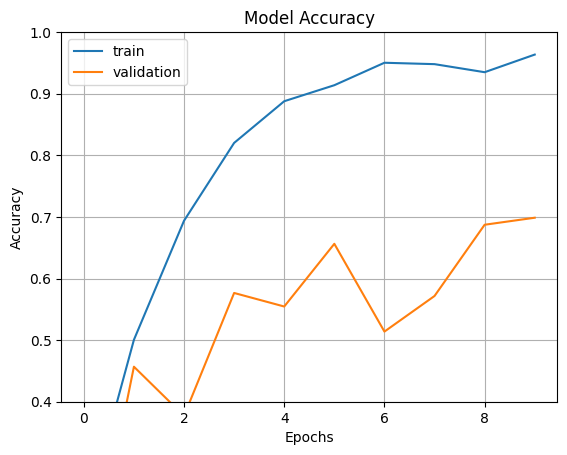

In [113]:
graph_result(history)